In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv("experiment2/postprocessing/combined_data.csv")

In [62]:
df

,meanRF,varRF,meanNRF,varNRF,HighSupportCladesProp,likelihoodESS,priorESS,treeLikelihoodESS,tier,ZIP,leaves,independent_sites
0,11.469614,3.183104,0.819258,0.016240,0.111111,8535.557568,7583.399461,8535.557568,1,independent,10,10
1,11.094545,3.658727,0.792468,0.018667,0.111111,8658.910863,7625.390996,8658.910863,2,"ZIP(0.2, 3.75)",10,10
2,4.651261,2.907812,0.332233,0.014836,0.444444,9001.000000,9715.883829,9001.000000,3,"ZIP(0.2, 3.75)",10,10
3,2.854350,1.358450,0.203882,0.006931,0.666667,5849.022996,9001.000000,5849.022996,4,"ZIP(0.2, 3.75)",10,10
4,7.155205,1.906687,0.511086,0.009728,0.571429,3330.025255,1219.452722,3330.025255,2,"ZIP(0.5, 6.0)",10,10
...,...,...,...,...,...,...,...,...,...,...,...,...
4155,13.893567,4.351782,0.147804,0.000493,0.816327,6121.305821,2321.086405,6121.305821,3,"ZIP(0.7, 10.0)",50,200
4156,14.290412,6.868985,0.152026,0.000777,0.795918,5709.293074,3392.668218,5709.293074,4,"ZIP(0.7, 10.0)",50,200
4157,6.208199,4.005982,0.066045,0.000453,0.877551,6031.521814,2934.271759,6031.521814,2,"ZIP(0.9, 30.0)",50,200
4158,18.762360,3.142743,0.199600,0.000356,0.860465,4878.179483,78.165820,4878.179483,3,"ZIP(0.9, 30.0)",50,200


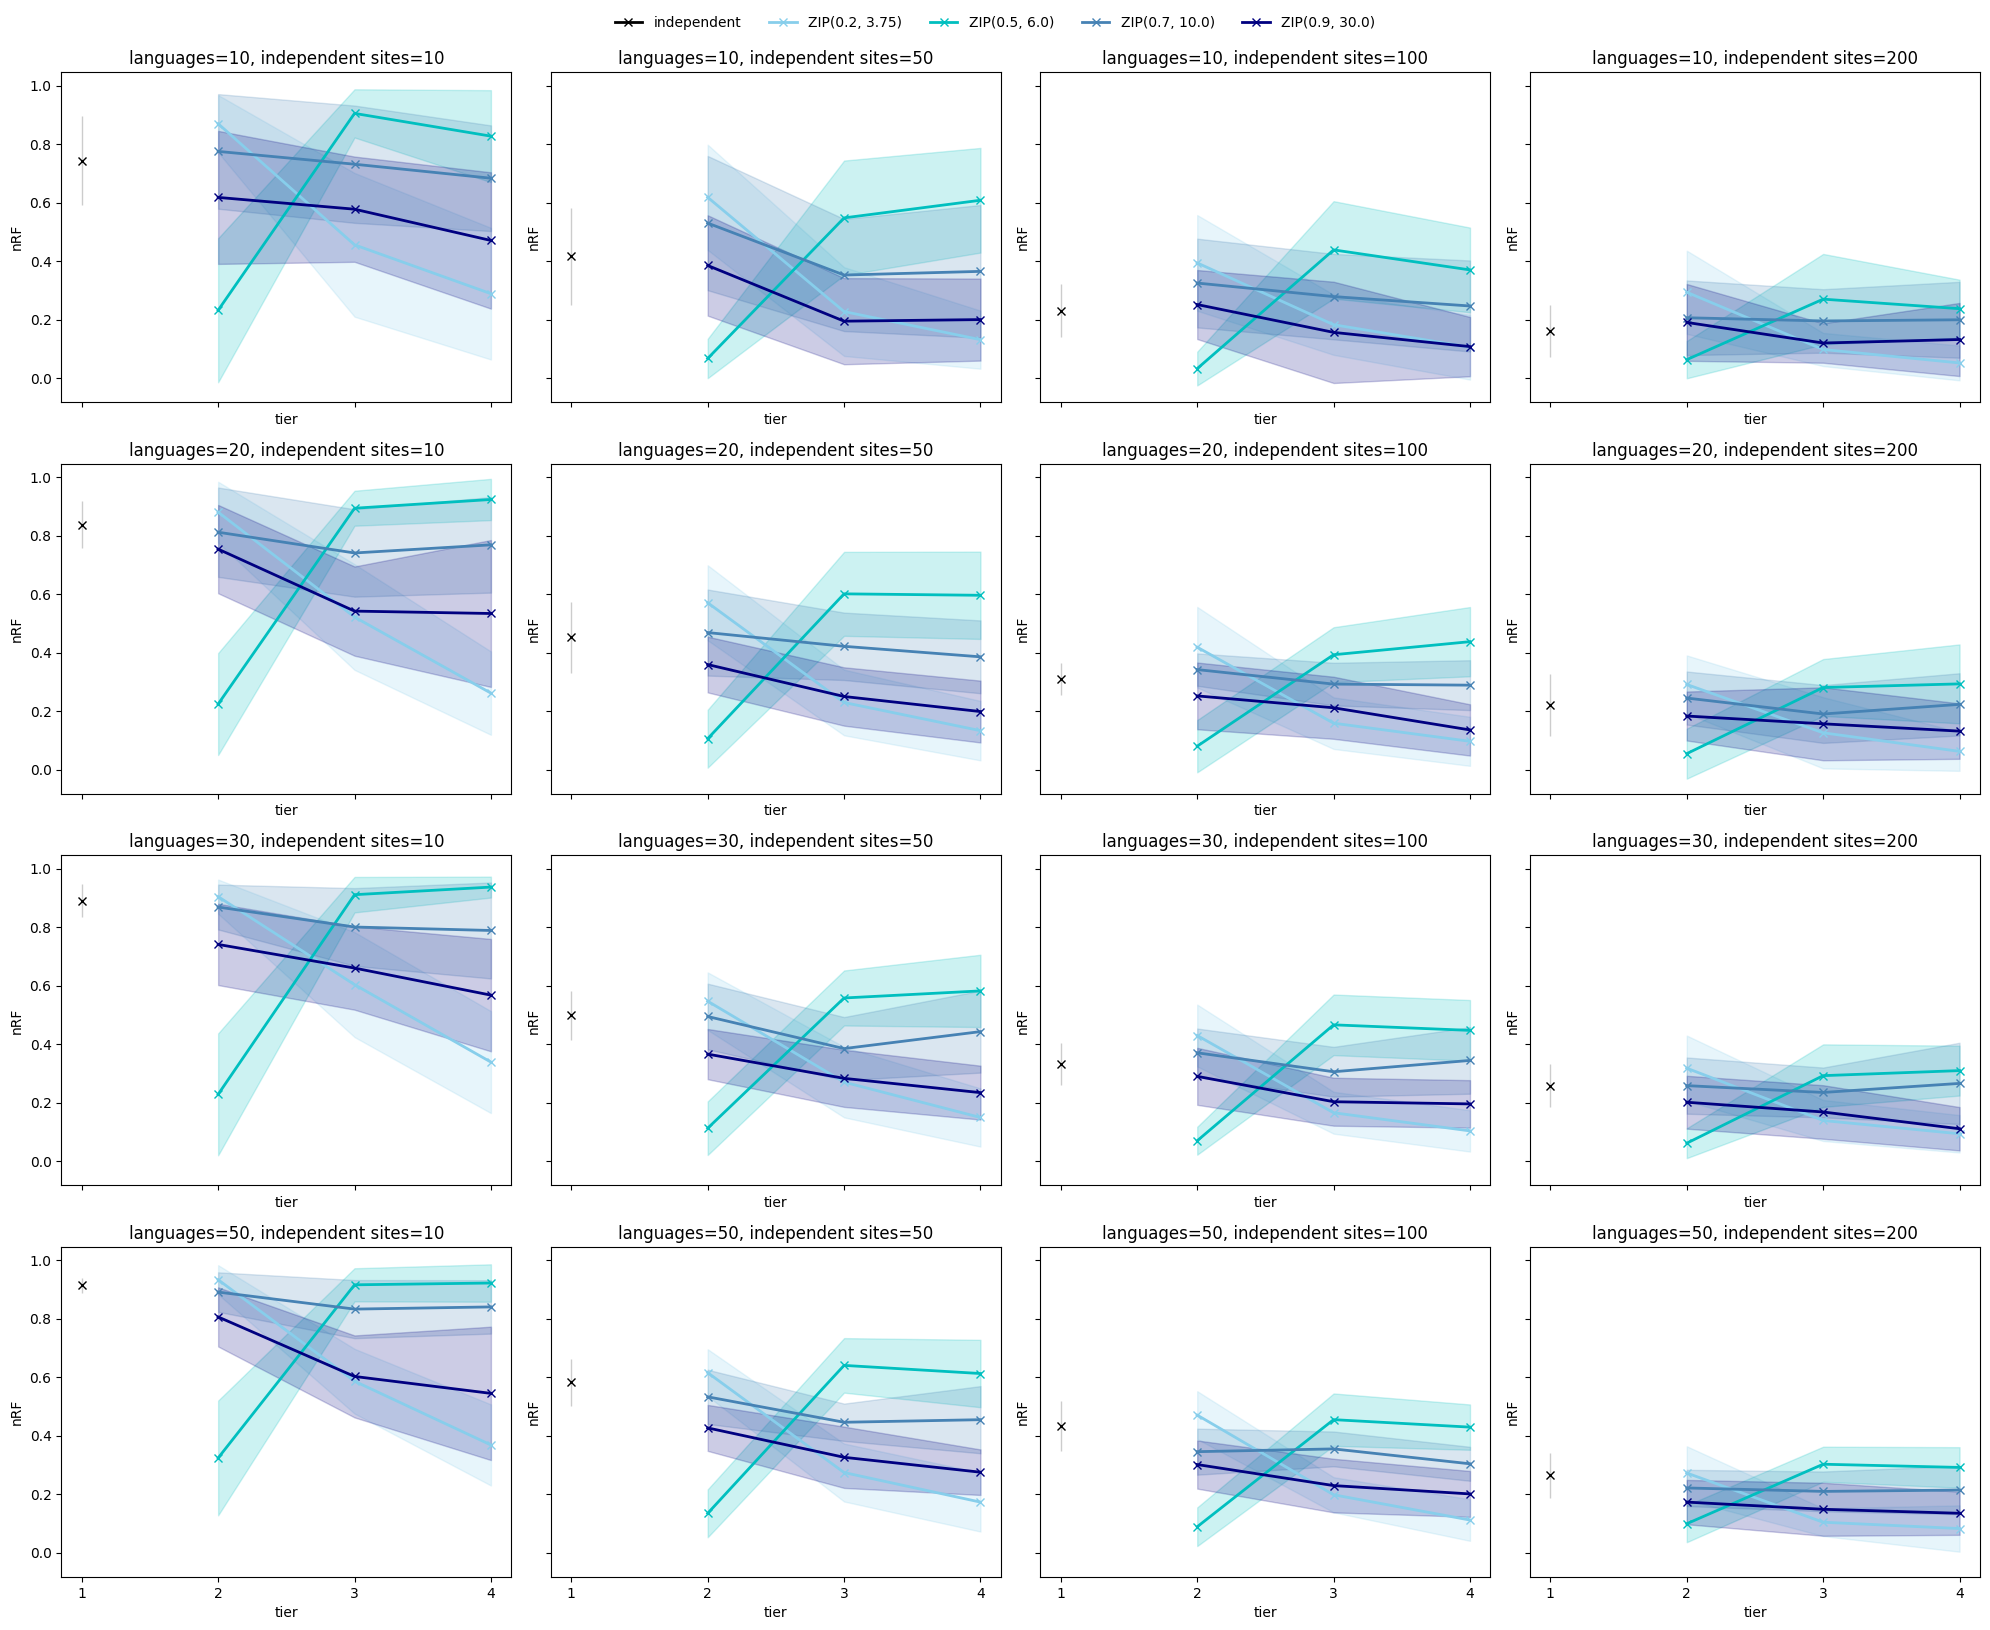

In [63]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "skyblue", "c", "steelblue", "navy"]

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue

        methods = d["ZIP"].unique()

        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]

            grouped = dm.groupby("tier")["meanNRF"]
            mean = grouped.mean()
            std = grouped.std()

            x = mean.index.values

            color = colors[k]

            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)

            ax.fill_between(
                x,
                mean - std,
                mean + std,
                color=color,
                alpha=0.2
            )

        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("nRF")
        ax.set_xticks([1, 2, 3, 4])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=min(6, len(labels)),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

- Clearly more independent data is better from the plot (compare blue dots from left to right)
- But with more independent data adding tiers to the data is less useful (marginal improvement decreases?)
- In most cases, having more dependent data improves the model recovery
- Interestingly, generation needs to be extremely selective or extremely widespread - having ZIP(0.5, 6) actually nullifies the effect of more dependent tiers


make uninteresting plots
- plot amount of data that was created for each step

In [45]:
df['priorESS']

0       7583.399461
1       7625.390996
2       9715.883829
3       9001.000000
4       1219.452722
           ...     
4155    2321.086405
4156    3392.668218
4157    2934.271759
4158      78.165820
4159      38.460924
Name: priorESS, Length: 4160, dtype: float64

209